# V58: Sorting Method Comparison - Momentum vs Sharpe vs Markowitz

## Tujuan Eksperimen

Notebook ini membandingkan **4 metode sorting** yang berbeda sebelum graph filtering:

### Metode Sorting yang Dibandingkan:

1. **Momentum Sorting (Baseline)**
   - Sort by: Average return (momentum)
   - Formula: `returns_window.mean()`
   - Fokus: Trend-following, return maksimal

2. **Sharpe Ratio Sorting**
   - Sort by: Risk-adjusted return per aset
   - Formula: `(mean_return * 252) / (std_return * √252)`
   - Fokus: Risk-adjusted performance

3. **Markowitz Weight Sorting**
   - Sort by: Optimal portfolio weight
   - Formula: Optimize full portfolio → sort by weight
   - Fokus: Portfolio contribution (consider covariance)

4. **Risk-Adjusted Momentum Sorting**
   - Sort by: Momentum / Volatility
   - Formula: `mean_return / std_return`
   - Fokus: Balance return & risk

### Hipotesis:
- **H1:** Sharpe sorting lebih stabil dari momentum
- **H2:** Markowitz sorting optimal tapi computationally heavy
- **H3:** Risk-adjusted momentum balance antara return & risk

### Parameter:
- Graph Strategy: Diversifikasi (korelasi ≤ 0.4)
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Markowitz Optimization Function

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization function defined!")

Markowitz optimization function defined!


In [5]:
# Asset Selection Methods with Different Sorting

def get_assets_momentum_sort(returns_window, corr_threshold=0.4):
    """Method 1: Sort by Momentum (Baseline)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Momentum
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_sharpe_sort(returns_window, corr_threshold=0.4):
    """Method 2: Sort by Sharpe Ratio"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Sharpe Ratio
    mean_ret = returns_window.mean() * 252
    std_ret = returns_window.std() * np.sqrt(252)
    sharpe = mean_ret / std_ret
    sharpe = sharpe.replace([np.inf, -np.inf], 0).fillna(0)
    assets = list(sharpe.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_markowitz_sort(returns_window, corr_threshold=0.4):
    """Method 3: Sort by Markowitz Weight"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Markowitz optimal weight
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        # Fallback to momentum if optimization fails
        momentum = returns_window.mean()
        assets = list(momentum.sort_values(ascending=False).index)
    else:
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_risk_adj_momentum_sort(returns_window, corr_threshold=0.4):
    """Method 4: Sort by Risk-Adjusted Momentum"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Risk-Adjusted Momentum (momentum / volatility)
    momentum = returns_window.mean()
    volatility = returns_window.std()
    risk_adj_mom = momentum / volatility
    risk_adj_mom = risk_adj_mom.replace([np.inf, -np.inf], 0).fillna(0)
    assets = list(risk_adj_mom.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

print("Asset selection methods with different sorting defined!")

Asset selection methods with different sorting defined!


In [6]:
# Simulation Function

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, 
                   selection_func, override_ma=None, fee=0.0025, 
                   g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Simulation function ready!")

Simulation function ready!


In [7]:
# Run All Strategies

print("Running simulations...\n")

# 1. Momentum Sorting (Baseline)
print("1. Momentum Sorting...")
momentum_sort = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                               get_assets_momentum_sort, override_ma=50)

# 2. Sharpe Ratio Sorting
print("2. Sharpe Ratio Sorting...")
sharpe_sort = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                             get_assets_sharpe_sort, override_ma=50)

# 3. Markowitz Weight Sorting
print("3. Markowitz Weight Sorting...")
markowitz_sort = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                                get_assets_markowitz_sort, override_ma=50)

# 4. Risk-Adjusted Momentum Sorting
print("4. Risk-Adjusted Momentum Sorting...")
risk_adj_sort = run_simulation(X_test.index, returns, test_probs, opt_t, market_index, 
                               get_assets_risk_adj_momentum_sort, override_ma=50)

# 5. Index Benchmark
lq45_idx = market_index.loc[X_test.index] / market_index.loc[X_test.index[0]] * 100

print("\n=== RESULTS ===")
print(f"Momentum Sort (Baseline):       {momentum_sort.iloc[-1].values[0]:.2f}")
print(f"Sharpe Ratio Sort:              {sharpe_sort.iloc[-1].values[0]:.2f}")
print(f"Markowitz Weight Sort:          {markowitz_sort.iloc[-1].values[0]:.2f}")
print(f"Risk-Adjusted Momentum Sort:    {risk_adj_sort.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                     {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS ===")
sharpe_vs_momentum = ((sharpe_sort.iloc[-1].values[0] / momentum_sort.iloc[-1].values[0]) - 1) * 100
markowitz_vs_momentum = ((markowitz_sort.iloc[-1].values[0] / momentum_sort.iloc[-1].values[0]) - 1) * 100
risk_adj_vs_momentum = ((risk_adj_sort.iloc[-1].values[0] / momentum_sort.iloc[-1].values[0]) - 1) * 100

print(f"Sharpe vs Momentum:             {sharpe_vs_momentum:+.2f}%")
print(f"Markowitz vs Momentum:          {markowitz_vs_momentum:+.2f}%")
print(f"Risk-Adj Momentum vs Momentum:  {risk_adj_vs_momentum:+.2f}%")

Running simulations...

1. Momentum Sorting...
2. Sharpe Ratio Sorting...
3. Markowitz Weight Sorting...
4. Risk-Adjusted Momentum Sorting...

=== RESULTS ===
Momentum Sort (Baseline):       205.60
Sharpe Ratio Sort:              182.98
Markowitz Weight Sort:          182.11
Risk-Adjusted Momentum Sort:    182.98
LQ45 Index:                     119.44

=== ANALYSIS ===
Sharpe vs Momentum:             -11.00%
Markowitz vs Momentum:          -11.43%
Risk-Adj Momentum vs Momentum:  -11.00%


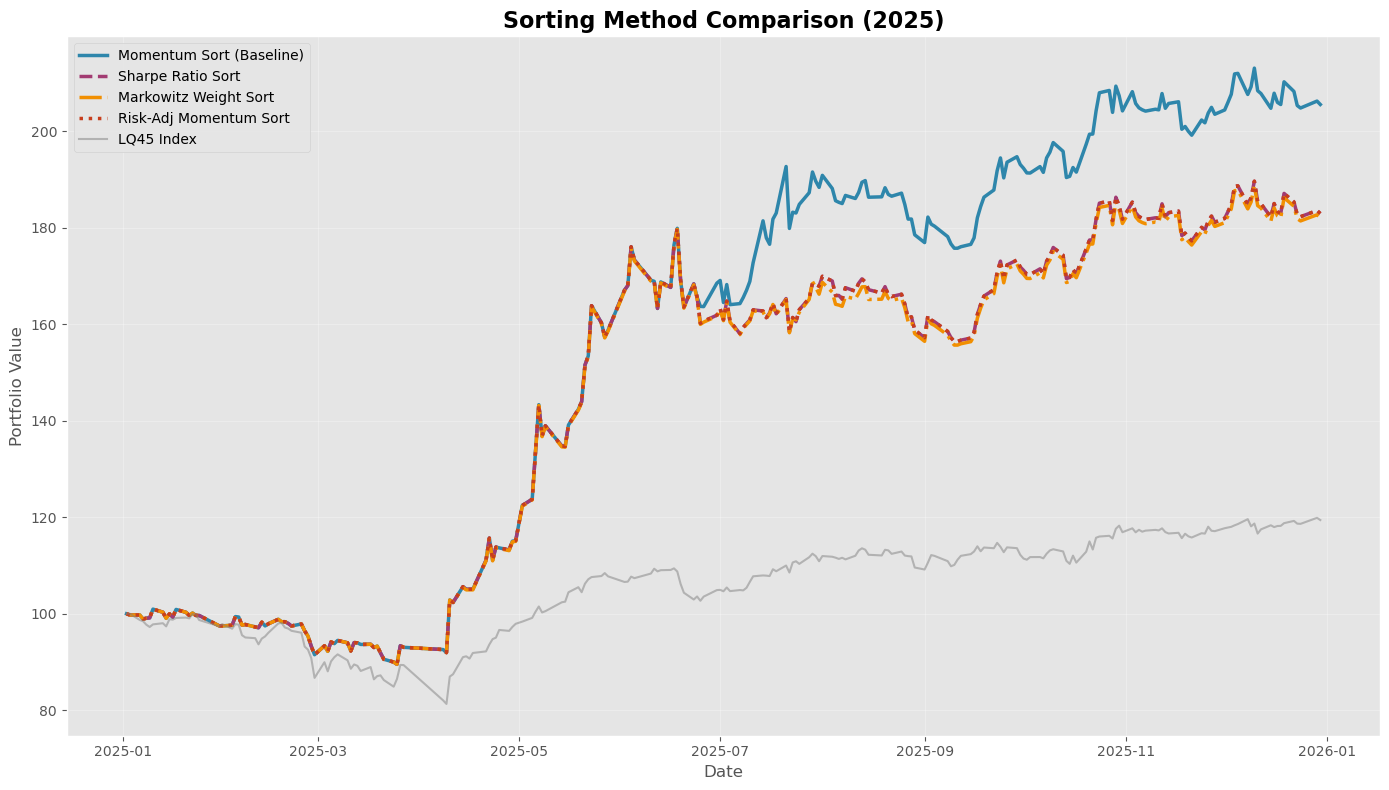


Visualization complete!


In [8]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(momentum_sort.index, momentum_sort['Portfolio_Value'], 
         label='Momentum Sort (Baseline)', linewidth=2.5, color='#2E86AB')
plt.plot(sharpe_sort.index, sharpe_sort['Portfolio_Value'], 
         label='Sharpe Ratio Sort', linewidth=2.5, color='#A23B72', linestyle='--')
plt.plot(markowitz_sort.index, markowitz_sort['Portfolio_Value'], 
         label='Markowitz Weight Sort', linewidth=2.5, color='#F18F01', linestyle='-.')
plt.plot(risk_adj_sort.index, risk_adj_sort['Portfolio_Value'], 
         label='Risk-Adj Momentum Sort', linewidth=2.5, color='#C73E1D', linestyle=':')
plt.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', alpha=0.5)

plt.title('Sorting Method Comparison (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [9]:
# Calculate Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics_momentum = calculate_metrics(momentum_sort['Portfolio_Value'])
metrics_sharpe = calculate_metrics(sharpe_sort['Portfolio_Value'])
metrics_markowitz = calculate_metrics(markowitz_sort['Portfolio_Value'])
metrics_risk_adj = calculate_metrics(risk_adj_sort['Portfolio_Value'])
metrics_index = calculate_metrics(lq45_idx)

results_df = pd.DataFrame({
    'Momentum Sort': metrics_momentum,
    'Sharpe Sort': metrics_sharpe,
    'Markowitz Sort': metrics_markowitz,
    'Risk-Adj Mom Sort': metrics_risk_adj,
    'LQ45 Index': metrics_index
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v58_sorting_method_comparison_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                   Total Return (%)  Volatility (%)  Sharpe Ratio  \
Momentum Sort                105.60           33.91          2.45   
Sharpe Sort                   82.98           32.50          2.15   
Markowitz Sort                82.11           32.54          2.14   
Risk-Adj Mom Sort             82.98           32.50          2.15   
LQ45 Index                    19.44           20.38          1.04   

                   Max Drawdown (%)  
Momentum Sort                -11.33  
Sharpe Sort                  -13.04  
Markowitz Sort               -13.35  
Risk-Adj Mom Sort            -13.04  
LQ45 Index                   -18.70  

Results exported to: v58_sorting_method_comparison_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **Momentum Sorting (Baseline)**:
   - Fokus: Pure trend-following
   - Expected: Return tinggi, volatilitas tinggi
   - Use case: Bullish market

2. **Sharpe Ratio Sorting**:
   - Fokus: Risk-adjusted return per aset
   - Expected: Sharpe ratio lebih tinggi, lebih stabil
   - Use case: Risk-conscious investor

3. **Markowitz Weight Sorting**:
   - Fokus: Portfolio contribution (covariance-aware)
   - Expected: Optimal diversification
   - Use case: Sophisticated portfolio management

4. **Risk-Adjusted Momentum Sorting**:
   - Fokus: Balance return & risk
   - Expected: Middle ground antara momentum & sharpe
   - Use case: Balanced approach

### Key Insights:

**Jika Sharpe Sort > Momentum:**
- Risk adjustment penting untuk long-term performance
- Volatilitas drag down returns

**Jika Markowitz Sort > Others:**
- Covariance structure matters
- Portfolio-level thinking superior

**Jika Risk-Adj Momentum > Others:**
- Simple ratio (momentum/vol) effective
- Best balance antara simplicity & performance

### Rekomendasi:
- **Best Sharpe Ratio** → Pilih untuk risk-adjusted return
- **Best Total Return** → Pilih untuk aggressive growth
- **Lowest Drawdown** → Pilih untuk capital preservation
- **Computational Cost** → Markowitz sort paling mahal